# Zabezpieczanie sieci komputerowych grafową siecią neuronową (GNN)

**Wiktoria Białasik · Maja Stefanowicz**

Matematyczne Fundamenty Informatyki · temat 13

Mamy ograniczony budżet i możemy lepiej zabezpieczyć tylko kilka komputerów w sieci. Chcemy, żeby sieć neuronowa sama wskazała, które z nich wybrać, tak aby atak rozprzestrzeniał się jak najwolniej.

## 1. Problem

Sieć komputerową przedstawiamy jako graf: komputery to wierzchołki, a połączenia między nimi to krawędzie. Atak (na przykład robak sieciowy) zaczyna się w jednym komputerze i przenosi się po połączeniach na kolejne, podobnie jak choroba zakaźna.

Nie da się jednakowo zabezpieczyć całej sieci, bo to kosztuje. Możemy mocniej utwardzić tylko *k* wybranych komputerów. Cały problem sprowadza się więc do pytania: **które komputery wybrać, żeby atak rozszedł się jak najwolniej?**

## 2. Jak wygląda sieć i jak działa atak

Testujemy nasze podejście na grafach złożonych z dwóch gęstych skupisk komputerów połączonych kilkoma pojedynczymi łączami (mostami). Taka struktura przypomina dwie podsieci spięte wąskim gardłem i dobrze pokazuje, gdzie obrona jest naprawdę ważna.

Atak symulujemy modelem epidemicznym (SI/SIR): w każdym kroku zarażony komputer z pewnym prawdopodobieństwem zaraża swoich sąsiadów.

Utwardzenie komputera daje mu **dwa parametry bezpieczeństwa** (tego wymagało zadanie), które działają niezależnie:

1. **mniejsza podatność** — trudniej go zarazić (twarda bariera: decyduje, *które* komputery w ogóle padną),
2. **opóźnienie** — nawet jeśli zostanie zarażony, przez kilka kroków nie zaraża dalej (spowalniacz: nie zmienia, ilu komputerów ostatecznie padnie, ale *opóźnia* rozejście się ataku).

Co ważne, bariera jest **częściowa**, a nie pełna. Gdyby utwardzony komputer był całkowicie odporny, nigdy by się nie zaraził — a wtedy opóźnienie nie miałoby czego spowalniać. Dzięki częściowej odporności oba parametry naprawdę działają.

Jakość obrony mierzymy liczbą komputerów **dotkniętych atakiem do ustalonego kroku T** (im mniej, tym wolniej rozchodzi się atak). Ta miara reaguje na oba parametry naraz: barierę (mniej komputerów pada) i opóźnienie (atak rozchodzi się wolniej, więc do kroku T zdąży dotknąć mniej komputerów).

/Users/maja_stefanowicz/matematyczne_fundamenty_matematyczne/gnn-network-defense/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


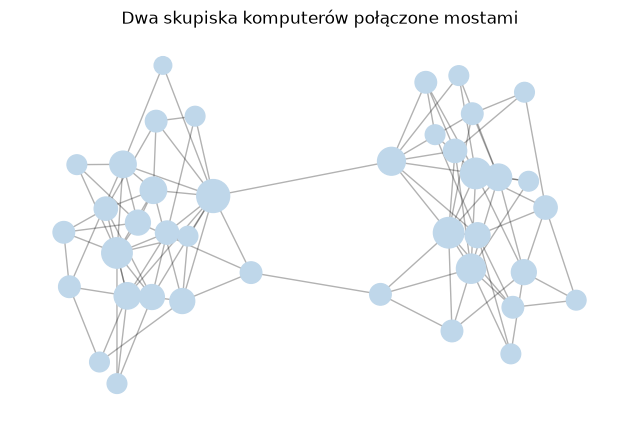

In [1]:
# Przykładowy graf: dwa klastry + mosty
import matplotlib.pyplot as plt
import networkx as nx
from src.graphs import generate_two_cluster_graph

G = generate_two_cluster_graph(40, m=3, n_bridges=2, seed=1)
pos = nx.spring_layout(G, seed=42)
deg = dict(G.degree())
sizes = [80 + 40 * deg[v] for v in G.nodes()]
plt.figure(figsize=(8, 5))
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color='#bfd7ea')
plt.title('Dwa skupiska komputerów połączone mostami')
plt.axis('off'); plt.show()

## 3. Punkt odniesienia: wyrocznia

Żeby wiedzieć, jak dobry jest nasz model, potrzebujemy punktu odniesienia. Zbudowaliśmy więc wyrocznię, która znajduje bardzo dobry zestaw komputerów do utwardzenia. Robi to metodą prób i błędów: wielokrotnie symuluje atak dla różnych wyborów i sprawdza, który wypada najlepiej.

Problem w tym, że jest bardzo wolna. Dla jednego grafu potrzebuje około 12 sekund, bo musi przeprowadzić tysiące symulacji. W praktyce nie da się jej tak używać.

Dlatego traktujemy wyrocznię jak nauczyciela: pokazuje ona modelowi dobre odpowiedzi podczas treningu, a my chcemy, żeby sieć neuronowa nauczyła się podejmować podobne decyzje samodzielnie i znacznie szybciej.

## 4. Nasz model

Każdy komputer opisujemy czterema liczbami mówiącymi o jego położeniu w sieci: liczbą połączeń, tym jak często leży na drogach między innymi komputerami, jak bardzo jego sąsiedzi są ze sobą połączeni oraz jak blisko jest do reszty sieci.

Na tych danych uczymy grafową sieć neuronową (GCN). Dla każdego komputera zwraca ona liczbę od 0 do 1 mówiącą, jak bardzo opłaca się go utwardzić. Sieć uczy się, porównując swoje odpowiedzi z podpowiedziami wyroczni.

Najważniejsza cecha takiej sieci jest taka, że przy liczeniu wyniku dla danego komputera bierze ona pod uwagę także jego sąsiadów. Dzięki temu nie patrzy na komputer w oderwaniu, ale rozumie jego rolę w całej strukturze. To pozwala jej zauważyć most: komputer, który ma niewiele połączeń, ale leży dokładnie między dwoma skupiskami.

## 5. Trening

Model trenowaliśmy na 200 grafach, z których część odłożyliśmy na walidację, żeby sprawdzać go na sieciach, których nie widział podczas nauki. Na wykresie widać, że błąd spada i się stabilizuje, a wynik na walidacji nadąża za treningiem. To znaczy, że model faktycznie się uczy i nie zapamiętuje danych na pamięć.

Po drodze trafiliśmy na ciekawy problem: na początku model wszystkim komputerom dawał niemal taką samą ocenę, bo podpowiedzi wyroczni były zbyt zaszumione. Poprawiliśmy sposób ich liczenia i wtedy model zaczął naprawdę rozróżniać komputery.

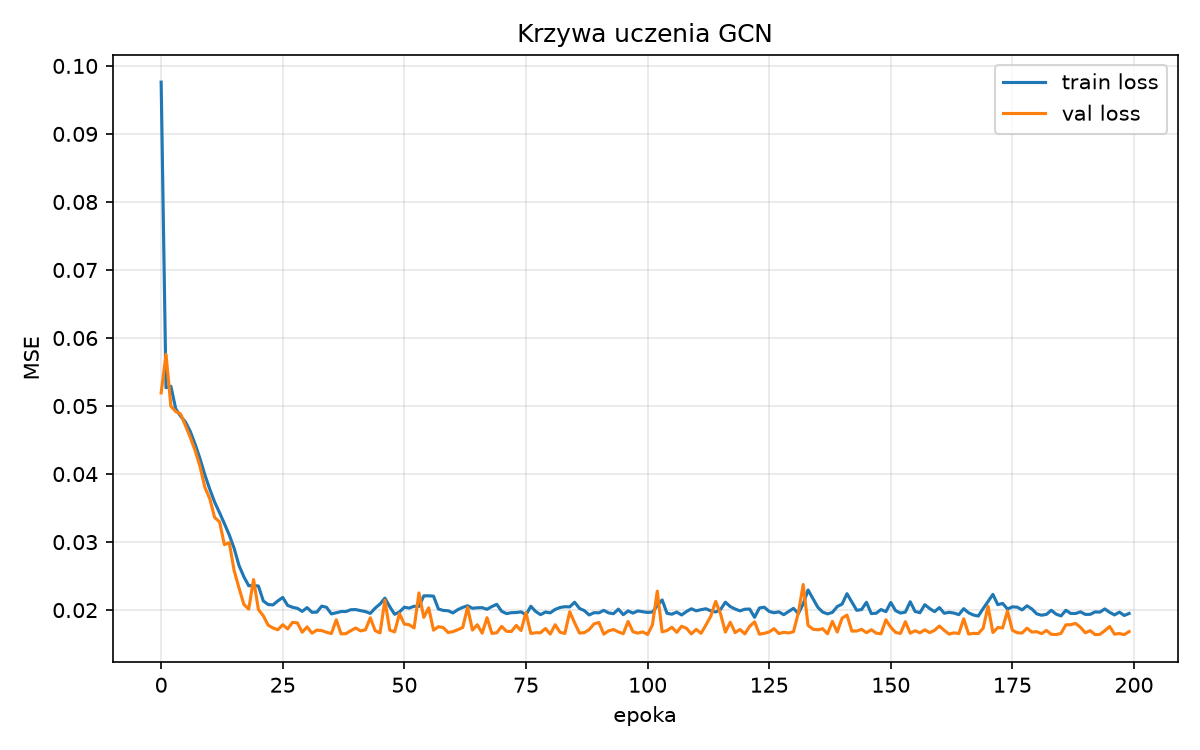

In [2]:
from IPython.display import Image
Image('data/learning_curve.png', width=720)

## 6. Wyniki

Porównaliśmy nasz model z prostszymi sposobami wyboru komputerów do utwardzenia. W każdym przypadku utwardzamy 5 komputerów i sprawdzamy, ilu komputerów średnio dotknie atak **do kroku T** (czyli jak szybko się rozchodzi). Im mniej, tym wolniejsza propagacja i lepsza obrona. W ostatniej kolumnie podajemy też finalny zasięg ataku.

| sposób wyboru | dotknięci do T | czas decyzji | finalny zasięg |
|-----------|---------:|-------------:|---------:|
| brak obrony | 33.9 | — | 35.7 |
| losowo | 28.2 | 0.04 ms | 34.6 |
| najwięcej połączeń | 22.6 | 0.03 ms | 31.6 |
| **nasz model (GNN)** | **19.4** | 0.66 ms | 26.5 |
| pozycja pośrednia | 18.4 | 2.35 ms | 25.2 |
| wyrocznia | 19.2 | 16 247 ms | 27.0 |

Czytajmy tabelę od góry. Bez żadnej obrony atak dotyka prawie 34 komputerów. Wybór losowy niewiele pomaga (28,2). Najprostszy sensowny pomysł — utwardzanie komputerów z największą liczbą połączeń — schodzi do 22,6, ale wciąż wypada słabo. Pomija mosty, bo te mają mało połączeń, a właśnie przez nie atak przedostaje się z jednego skupiska do drugiego.

Nasz model (19,4) radzi sobie znacznie lepiej i **praktycznie dorównuje wyroczni** (19,2). Sam nauczył się, że ważne są komputery leżące na styku skupisk. Co najważniejsze, decyzję podejmuje w ułamku milisekundy, podczas gdy wyrocznia potrzebuje na to około 16 sekund — model jest tu jakieś 24 tysiące razy szybszy.

Dla uczciwości: jedna z prostych miar (pozycja pośrednia, czyli betweenness) jest tu odrobinę lepsza od naszego modelu (18,4). Warto jednak pamiętać, że model nie dostał tej reguły z góry, tylko sam doszedł do niej na podstawie surowych cech.

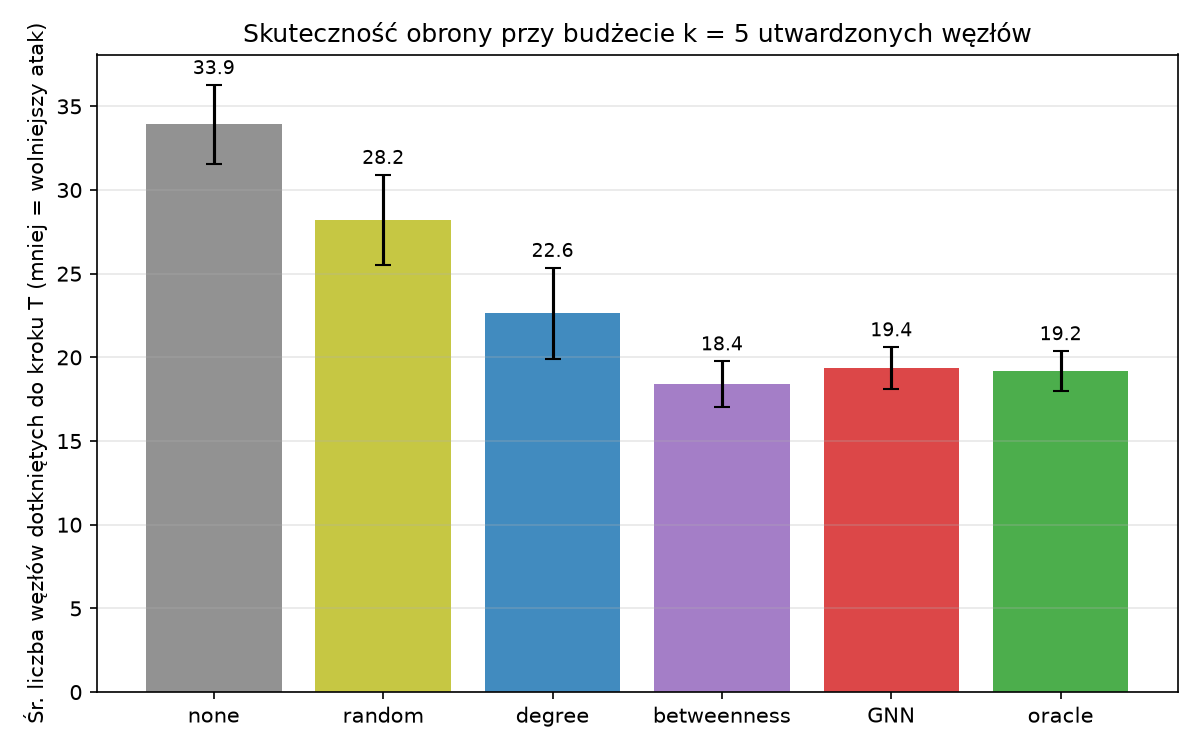

In [3]:
from IPython.display import Image
Image('data/comparison.png', width=720)

## 7. Zobaczmy to w działaniu

Na koniec ta sama symulacja ataku puszczona na dwóch identycznych sieciach. Atak startuje z tego samego komputera i przebiega tak samo. Jedyna różnica polega na tym, że po prawej stronie utwardziliśmy komputery wskazane przez nasz model.

Po lewej stronie atak szybko rozlewa się na obie części sieci. Po prawej widać działanie obu parametrów bezpieczeństwa: utwardzone mosty są trudniejsze do zarażenia (bariera), a gdy już padną, przez kilka kroków nie przepuszczają ataku dalej (opóźnienie). Dzięki temu atak rozchodzi się wyraźnie wolniej i przez długi czas drugie skupisko pozostaje nietknięte.

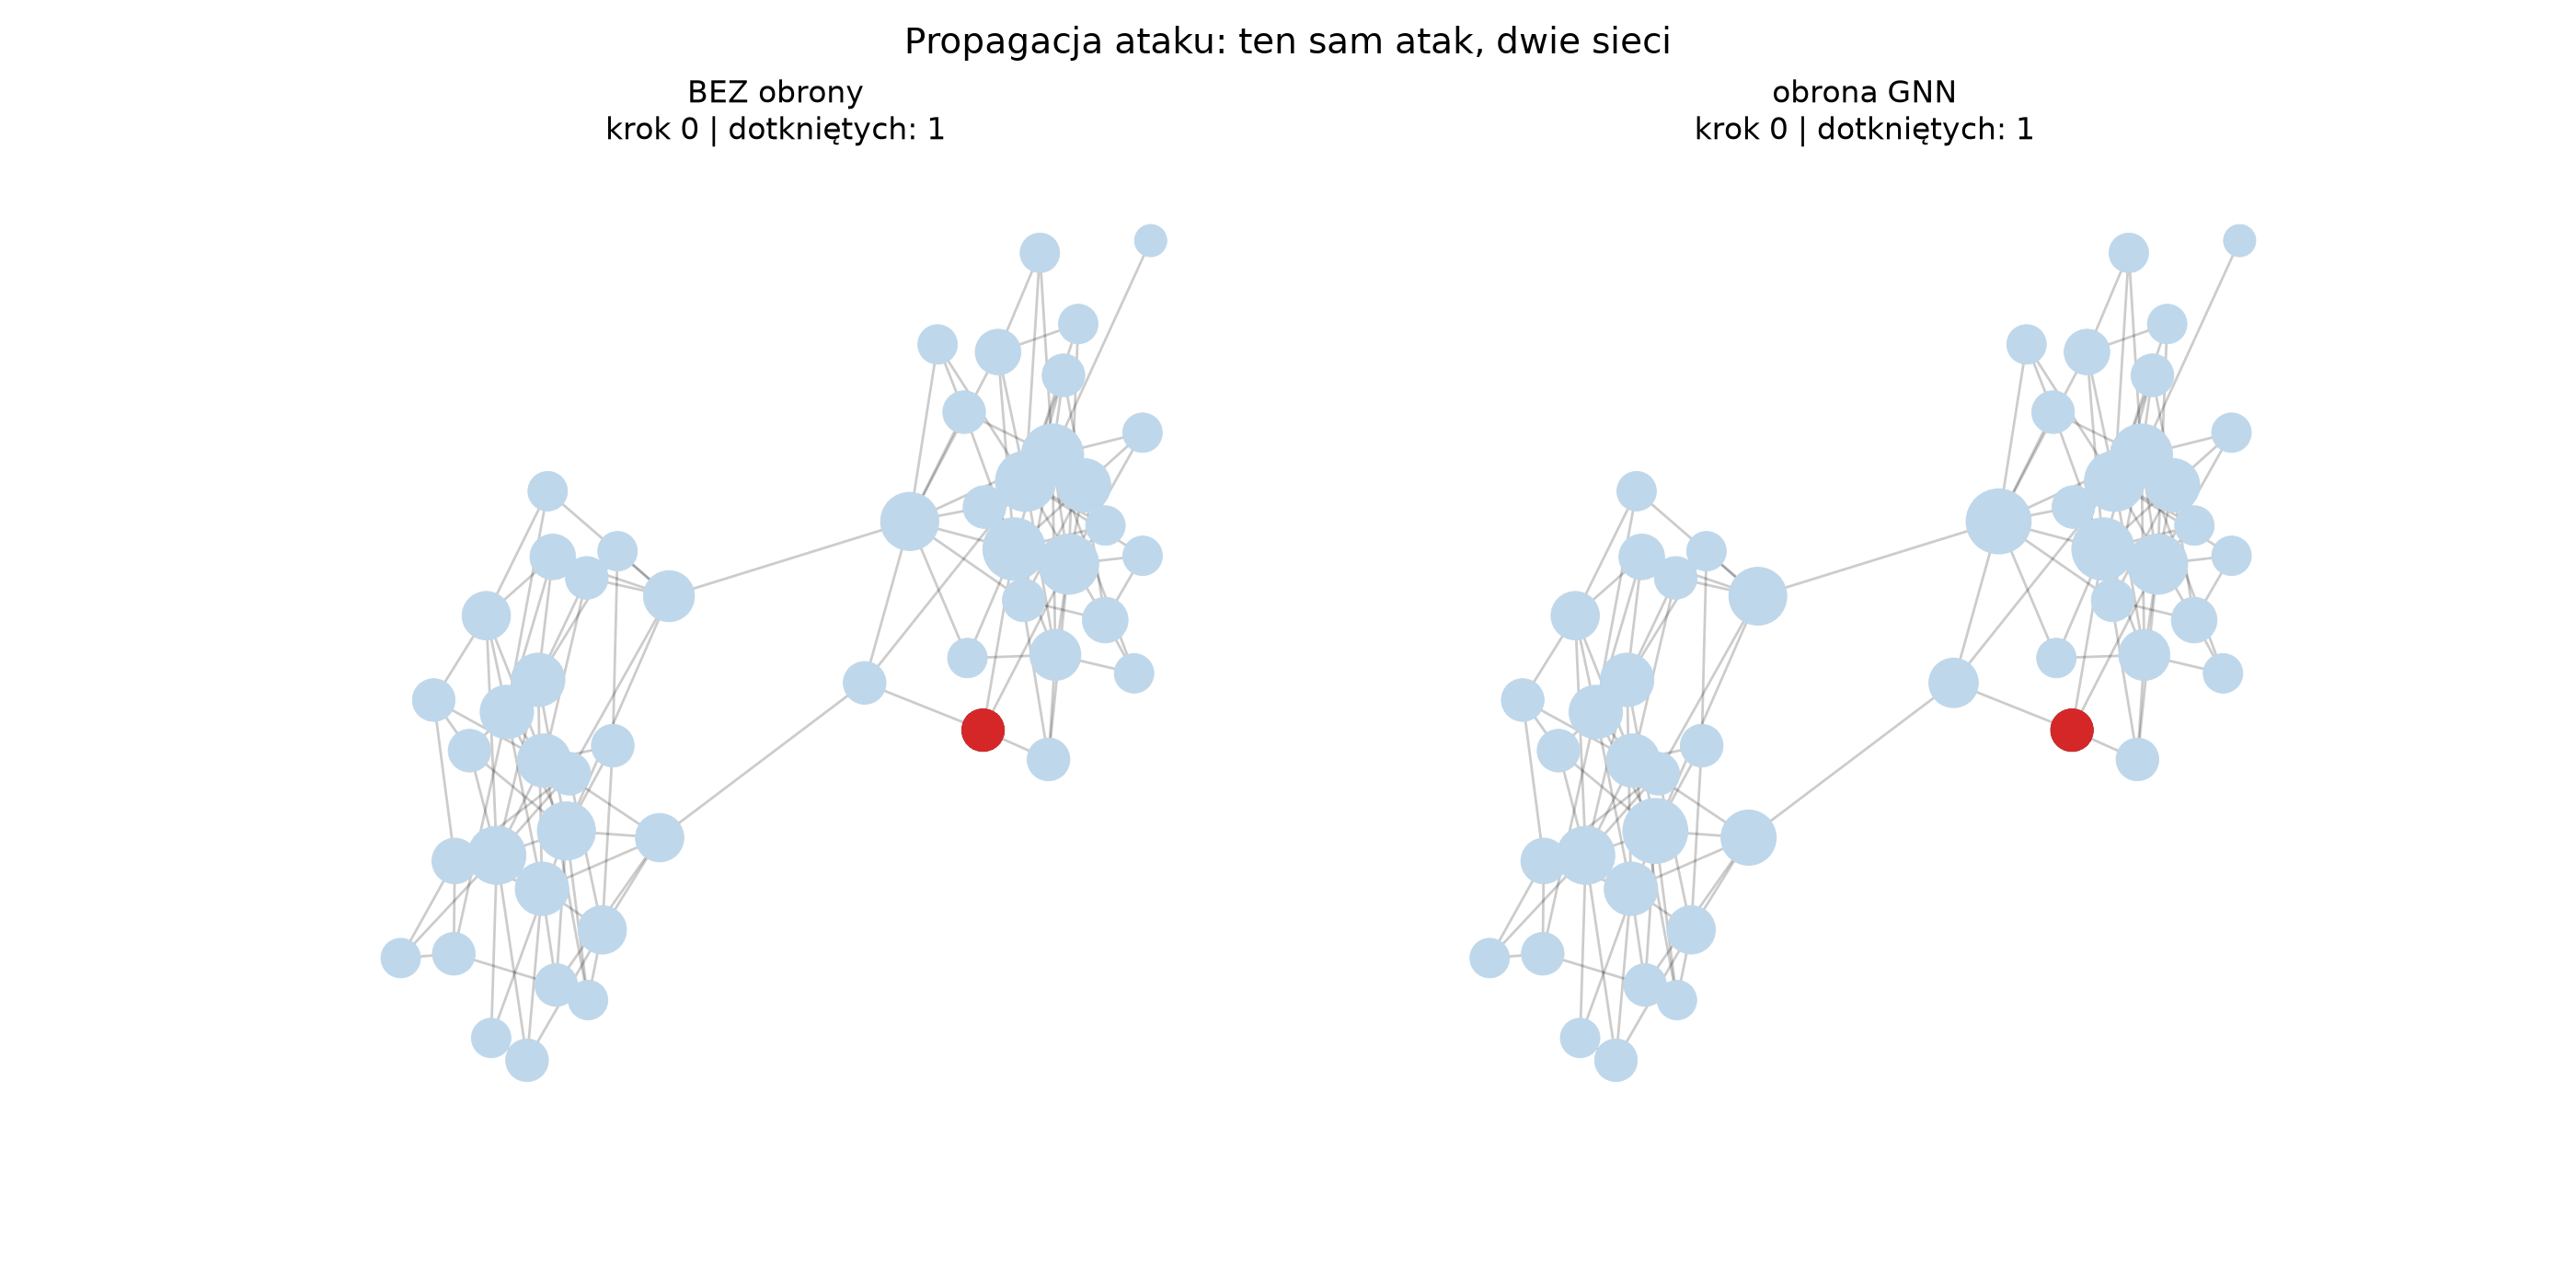

In [4]:
from IPython.display import Image
Image('data/compare.gif')   # animacja odtwarza się w notebooku

## 8. Podsumowanie

Udało nam się nauczyć sieć neuronową wybierania komputerów do zabezpieczenia tak, żeby spowolnić atak. Model sam doszedł do tego, że kluczowe są komputery łączące różne części sieci, i radzi sobie prawie tak dobrze jak wolna wyrocznia, podejmując decyzję natychmiast.

Trzeba pamiętać o ograniczeniach. Pracowaliśmy na sieciach generowanych sztucznie, a obrona jest jednorazowa, czyli wybieramy komputery raz, przed atakiem.

Naturalne kierunki rozwoju to większe i bardziej realistyczne sieci, obrona reagująca już w trakcie ataku oraz uwzględnienie kierunku połączeń.

Dziękujemy za uwagę.